<a href="https://colab.research.google.com/github/jacobw59/PhysicsI_Labs/blob/main/phy122_2body.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2 Body Motion \& Collisions

### <font color='Red'> **Jacob Williamson** </font>


### <font color='Red'> **5/3/2025** </font>

# Objective

### To Understand Velocity Verlet Applied to 2-body systems, including their mutual interaction and thus their inevitable collisions.

# Introduction


## **2 Body Motion**
### So far we have only considered motion of a single particle. We know that reality is more complex, and thus here we consider our largest system yet, 2 particles! Both of these particles have their own equation-of-motion \begin{align} m_1\ddot{\mathbf{x}}_1 &= \mathbf{f}_{12} \\ m_2\ddot{\mathbf{x}}_2 &= \mathbf{f}_{21} \end{align} for positions of particle $\mathbf{x}_1$ and $\mathbf{x}_2$ respectively, interacting with a force between the particles $\mathbf{f}(\mathbf{x}_1, \mathbf{x}_2)$. Instead of a two-variable force, we may decrease the degrees-of-freedom by defining the inter-particle displacement: \begin{align} \Delta \mathbf{x}_{12} &= \mathbf{x}_1 - \mathbf{x}_2 \quad.\end{align} Therefore the inter-particle force is instead $\mathbf{f}(\mathbf{x}_{12})$ which is shortened to $\mathbf{f}(\mathbf{x}_{12}) = \mathbf{f}_{12}$. Note by virtue of Newton's 3rd Law, the force acting on particle 2 is the opposite: $\mathbf{f}_{21} = -\mathbf{f}_{12}$.


### In order to alleviate the abstraction, here we consider a common and simple two-body interaction force of a spring. That is the aforementioned force is: \begin{align} \mathbf{f}(\mathbf{x}_{12}) = \mathbf{f}_{12} = 4\mathscr{E}\left( \frac{12}{R^{13}} - \frac{6}{R^{7}}\right)\frac{\Delta \mathbf{x}_{12}}{R},\quad\quad\quad R = |\mathbf{x}_{12}| = |\mathbf{x}_{21}|. \end{align} The parameter $\mathscr{E}$ is a scalar in units of energy, and describes the cohesive energy of this potential.

## **Momentum-Verlet**
### Here we consider the Momentum-Verlet integrator, with the equations of:\begin{align} \mathbf{x}(t+1) &= \mathbf{x}(t) + \left( \mathbf{p}(t) \,dt + \mathbf{f}(t) \frac{dt^2}{2} \right) \frac{1}{m} \\ \mathbf{f}(t+1) &= \,\,.... \\ \mathbf{p}(t+1) &= \mathbf{p}(t) + \frac{\left( \mathbf{f}(t) + \mathbf{f}(t+1) \right) \,dt}{2} \end{align} applied at every time-step.


## **Energy of the System**
### We now may calculate the energy of the system. We may partition the energy into 1-body and 2-body contributions. Here the 1-body contribution is known as the *kinetic-energy*, it is considered a 1-body contribution because it is only a function of each body independent of one another. Its functional form, in terms of momentum is: \begin{align} K &= \frac{\mathbf{p}^2_1}{2m} + \frac{\mathbf{p}^2_2}{2m} \quad. \end{align} Next the 2-body contribution, is the energy of the interaction, this is known as the *potential-energy*. It exists by virtue of the partciles not being in isolation, but interacting with something. Notice its functional form cannot be seperated like the kinetic-energy (1-body interaction): \begin{align} U(R) &= 4\mathscr{E} \left( \frac{1}{R^{12}} - \frac{1}{R^{6}} \right) \quad\quad.\end{align} With $\mathscr{E}$ is the same parameter defined earlier. Notice that we may apply: \begin{align} f_{12} &= - \frac{\partial U(R)}{\partial R} \,\frac{ \Delta \mathbf{x}_{12} }{R} \quad, \\ f_{21} &= - \frac{\partial U(R)}{\partial R} \,\frac{ \Delta \mathbf{x}_{21} }{R}\quad. \end{align}


## **Collisions**
### Now we consider collisions between the two particles. For a closed system (one with no friction) the total energy and momentum must be conserved. Here we will be considering closed collisions with the aforementioned Lennhard-Jones interaction.


## **Elastic Collisions**
### An elastic collision is an event whereby the particles exchange momentum, but the total kinetic energy is conserved.

## **Inelastic Collisions**
### An inelastic collision is an event whereby the particles exchange momentum, but the total kinetic energy is **not** conserved (although for closed systems the total energy is conserved). This means for inelastic collisions some kinetic energy was converted to potential energy.

### In particular, we would like to see a collision of two particles/bodies, after which they are bound with each other (as shown in the example).

## Simulation Tips

### For clearer simulation demonstration of elastic collisions should have alot of initial kinetic energy (larger initial velocities), the inelastic simulation should have low initial kinetic energy (smaller initial velocities).

### Make sure you have a sufficiently small time-step $\delta t$ to fully capture the collision-event.

### Let's import the necessary modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm
from numpy import arange, array, zeros

π = np.pi

## Example Code for Collisions

In [2]:
Δt = 0.001 ## s (time-step / detector resolution)
T  = arange(0, 10, Δt) ## total time array from 0 to 10 seconds

## --- INITIAL CONDITIONS ---

m_i  = array([2., 4.]) ## kg : masses of the two particles
R_ix = array([[-1., 0., 0.],    ## Particle 1 initial position (m)
              [ 4., 0., 0.]])   ## Particle 2 initial position (m)
V_ix = array([[2.50, 0., 0.],   ## Particle 1 initial velocity (m/s)
              [0.,    0., 0.]]) ## Particle 2 initial velocity (m/s)

p_ix  = m_i[:, None]*V_ix ## kg·m/s : momentum for both particles (mass × velocity)
f_ix  = zeros((2,3))      ## N : initialize force vectors for both particles to zero

## --- ARRAYS TO SAVE TRAJECTORIES & ENERGIES ---

R_tix = zeros( (len(T), R_ix.shape[0], R_ix.shape[1] ) ) ## particle positions over time
p_tix = zeros( (len(T), R_ix.shape[0], R_ix.shape[1] ) ) ## particle momenta over time
K_t   = zeros(len(T)) ## kinetic energy at each time step
U_t   = zeros(len(T)) ## potential energy at each time step

## --- MOMENTUM-VERLET TIME INTEGRATION LOOP ---
for t in range(len(T)):

    ## 1. Update positions using current momentum and force
    R_ix  += (p_ix * Δt + f_ix * Δt**2/2)/m_i[:, None]

    ## 2. Save current positions and momenta
    R_tix[t] = 1.*R_ix
    p_tix[t] = 1.*p_ix

    ## 3. Calculate the inter-particle displacement vector and distance
    Δx     = R_ix[0] - R_ix[1] ## vector from particle 2 to particle 1
    R      = norm(Δx)          ## magnitude (distance between particles)

    ## 4. Calculate the Lennard-Jones type force between particles
    F_ix   = 150*(12/R**13 - 6/R**7) * array([Δx, -Δx])/R

    ## 5. Update momentum using average of previous and current forces
    p_ix  += ( f_ix + F_ix ) * Δt/2
    f_ix   = F_ix ## new force becomes the previous force for next step

    ## 6. Save kinetic and potential energy at this step
    K_t[t] = (np.sum(p_ix[0]**2) / (2*m_i[0])
            + np.sum(p_ix[1]**2) / (2*m_i[1]) )
    U_t[t] = 150*(1/R**12 - 1/R**6)


## Plots

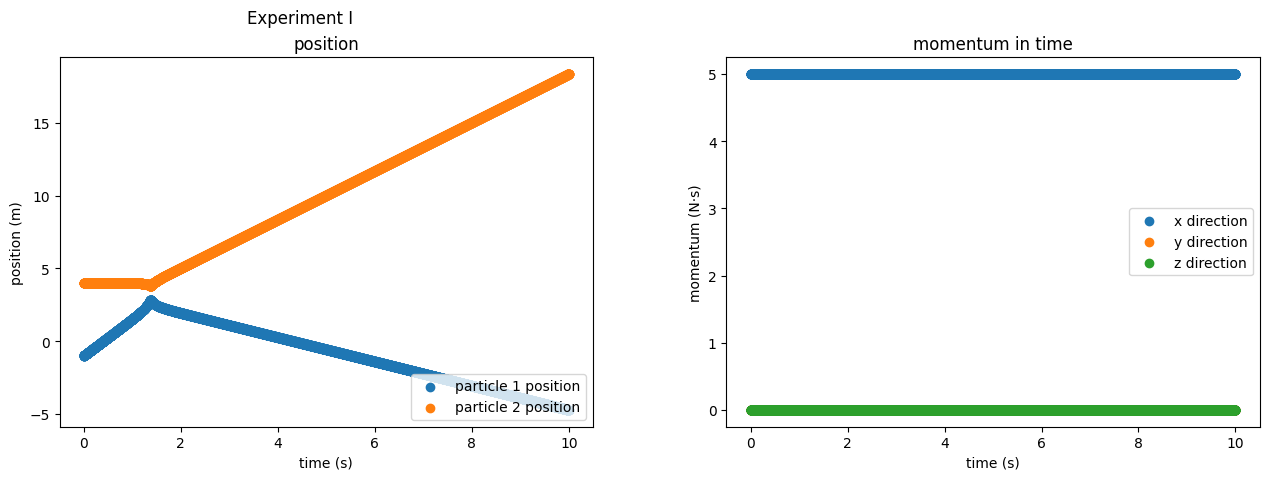

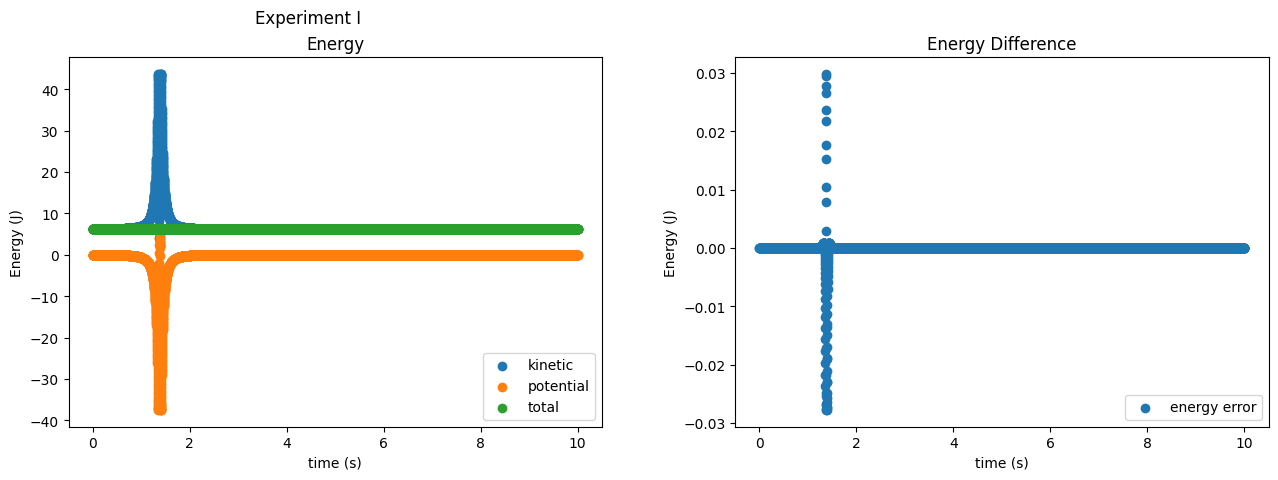

In [3]:
## ------------------- PLOTS -------------------

fig, (ax1, ax2) = plt.subplots(1,2)
fig.suptitle('Experiment I') ## Title for the whole figure
fig.subplots_adjust(hspace=0.01, wspace=0.25, right=2) ## spacing between plots

### --- Position Trajectories of the Particles ---
ax1.scatter(T, R_tix[:, 0, 0], label="particle 1 position") ## particle 1 x-position vs time
ax1.scatter(T, R_tix[:, 1, 0], label="particle 2 position") ## particle 2 x-position vs time
ax1.set_title("position")
ax1.set(xlabel='time (s)', ylabel='position (m)')
ax1.legend(loc="lower right")

### --- Interparticle Displacement Plot (commented out for now) ---
# ax2.scatter(T, R_tix[:, 0, 0]-R_tix[:, 1, 0], label="interparticle displacement")
# ax2.set_title("relative displacement")
# ax2.set(xlabel='time (s)', ylabel='displacement (m)')
# ax2.legend(loc="lower right")

fig.show()

## --- Total Momentum in Time (to check momentum conservation) ---
p_tx = np.sum(p_tix, axis=1) ## total momentum vector at each time step

plt.scatter(T, p_tx[:,0], label="x direction") ## x-component of momentum
plt.scatter(T, p_tx[:,1], label="y direction") ## y-component of momentum
plt.scatter(T, p_tx[:,2], label="z direction") ## z-component of momentum
plt.title("momentum in time")
plt.xlabel("time (s)")
plt.ylabel("momentum (N·s)")
plt.legend()
plt.show()

## --- Energy in Time (kinetic, potential, and total) ---
fig, (ax1, ax2) = plt.subplots(1,2)
fig.suptitle('Experiment I')
fig.subplots_adjust(hspace=0.01, wspace=0.25, right=2)

## Plot kinetic, potential, and total energy vs time
ax1.scatter(T, K_t, label="kinetic")
ax1.scatter(T, U_t, label="potential")
ax1.scatter(T, K_t+U_t, label="total")
ax1.set_title("Energy")
ax1.set(xlabel='time (s)', ylabel='Energy (J)')
ax1.legend(loc="lower right")

## Plot energy conservation error over time
ax2.scatter(T, (K_t+U_t) - (K_t+U_t)[0], label="energy error")
ax2.set_title("Energy Difference")
ax2.set(xlabel='time (s)', ylabel='Energy (J)')
ax2.legend(loc="lower right")

fig.show()


#   <font color='Red'> **Elastic Scattering** </font>


###   <font color='Red'> Code: for the 2-body Velocity-Verlet Elastic Simulation </font>


In [4]:
## ------------------- ELASTIC SCATTERING SIMULATION -------------------

Δt = 0.001 ## s : time step (detector temporal resolution)
T = arange(0, 10, Δt) ## time array from 0 to 10 seconds

## --- PARAMETERS ---
γ    = 0.00 ## damping/friction coefficient (zero for elastic collisions)
m_i  = array([2., 4.]) ## kg : masses of particles

## --- INITIAL CONDITIONS ---
R_ix = array([[-1., 0., 0.],    ## Particle 1 initial position (m)
              [ 4., 0., 0.]])   ## Particle 2 initial position (m)
v_ix = array([[0.50, 0., 0.],   ## Particle 1 initial velocity (m/s)
              [0.,    0., 0.]]) ## Particle 2 initial velocity (m/s)

## --- INITIAL MOMENTUM ---
p_ix  = m_i[:, None]*v_ix ## kg·m/s : momentum vectors for both particles

## --- INITIAL FORCE (starts at zero) ---
f_ix  = zeros((2,3)) ## N

## --- ARRAYS TO SAVE DATA ---
R_tix = zeros( (len(T), R_ix.shape[0], R_ix.shape[1] ) ) ## position trajectories
p_tix = zeros( (len(T), R_ix.shape[0], R_ix.shape[1] ) ) ## momentum trajectories
K     = zeros(len(T)) ## kinetic energy over time
U     = zeros(len(T)) ## potential energy over time

## --- MOMENTUM-VERLET INTEGRATION LOOP ---
for t in range(len(T)):

    ## 1. Update positions
    R_ix  += (p_ix * Δt + f_ix * Δt**2 / 2)/m_i[:, None]

    ## 2. Save current positions and momenta
    R_tix[t] = 1.*R_ix
    p_tix[t] = 1.*p_ix

    ## 3. Calculate displacement and distance between particles
    Δx     = R_ix[0] - R_ix[1]
    R      = norm(Δx)

    ## 4. Compute force (note: '+' sign indicates repulsion for elastic)
    F_ix   = 150*(12/R**13 + 6/R**7) * array([Δx, -Δx])/R - γ * p_ix

    ## 5. Update momenta
    p_ix  += ( f_ix + F_ix ) * Δt / 2
    f_ix   = F_ix

    ## 6. Save kinetic and potential energy
    K[t]   = np.sum(p_ix[0]**2) / (2*m_i[0]) + np.sum(p_ix[1]**2) / (2*m_i[1])
    U[t]   = 150*(1/R**12 + 1/R**6)


###   <font color='Red'> Plot: Trajectory in Time </font>


In [ ]:
## ------------------- PLOT: TRAJECTORY IN TIME -------------------

fig, (ax1, ax2) = plt.subplots(1,2) ## create two subplots side by side
fig.suptitle('Experiment I') ## title for the entire figure
fig.subplots_adjust(hspace=0.01, wspace=0.25, right=2) ## adjust spacing between subplots

## --- Plot 1: Positions of both particles over time ---
ax1.scatter(T, R_tix[:, 0, 0], label="particle 1 position") ## x-position of particle 1
ax1.scatter(T, R_tix[:, 1, 0], label="particle 2 position") ## x-position of particle 2
ax1.set_title("position")
ax1.set(xlabel='time (s)', ylabel='position (m)')
ax1.legend(loc="lower right")

## --- Plot 2: Relative displacement between particles ---
ax2.scatter(T, R_tix[:, 0, 0]-R_tix[:, 1, 0], label="interparticle displacement")
ax2.set_title("relative displacement")
ax2.set(xlabel='time (s)', ylabel='displacement (m)')
ax2.legend(loc="lower right")

fig.show()


###   <font color='Red'> Plot: Total Momentum in Time </font>


In [ ]:
## ------------------- PLOT: TOTAL MOMENTUM IN TIME -------------------

p_tx = np.sum(p_tix, axis=1) ## total momentum at each time step (sum over particles)

## --- Plot momentum components over time ---
plt.scatter(T, p_tx[:,0], label="x direction") ## x-component of total momentum
plt.scatter(T, p_tx[:,1], label="y direction") ## y-component of total momentum
plt.scatter(T, p_tx[:,2], label="z direction") ## z-component of total momentum

plt.title("momentum in time")
plt.xlabel("time (s)")
plt.ylabel("momentum (N/s)")
plt.legend()
plt.show()


###   <font color='Red'> Plot: Energy (kinetic, potential, and total) in Time </font>

In [ ]:
## ------------------- PLOT: ENERGY IN TIME -------------------

fig, (ax1, ax2) = plt.subplots(1,2) ## two subplots side by side
fig.suptitle('Experiment I') ## title for the entire figure
fig.subplots_adjust(hspace=0.01, wspace=0.25, right=2) ## adjust spacing

## --- Plot 1: Kinetic, potential, and total energy ---
ax1.scatter(T, K, label="kinetic")      ## kinetic energy over time
ax1.scatter(T, U, label="potential")    ## potential energy over time
ax1.scatter(T, K+U, label="total")      ## total energy (should be constant for elastic)
ax1.set_title("Energy")
ax1.set(xlabel='time (s)', ylabel='Energy (J)')
ax1.legend(loc="lower right")

## --- Plot 2: Energy conservation check (error from initial total energy) ---
ax2.scatter(T, (K+U) - (K+U)[0], label="energy error")
ax2.set_title("Energy Difference")
ax2.set(xlabel='time (s)', ylabel='Energy (J)')
ax2.legend(loc="lower right")

fig.show()


#   <font color='Red'> **Inelastic Scattering** </font>


###   <font color='Red'> Code: for the 2-body Velocity-Verlet Inelastic Simulation </font>

In [ ]:
## ------------------- INELASTIC SCATTERING SIMULATION -------------------

Δt = 0.001 ## s : time step
tf = 100    ## final time (longer simulation to capture slow collision dynamics)
T = arange(0, tf, Δt) ## time array from 0 to 100 seconds

## --- PARAMETERS ---
γ    = 0.00 ## no friction/damping for this inelastic case (kinetic energy may still convert into potential)
m_i  = array([2., 4.]) ## kg : particle masses

## --- INITIAL CONDITIONS ---
R_ix = array([[-1., 0., 0.],    ## Particle 1 initial position (m)
              [ 4., 0., 0.]])   ## Particle 2 initial position (m)
v_ix = array([[0.05, 0., 0.],   ## Particle 1 initial velocity (m/s)
              [0.,    0., 0.]]) ## Particle 2 at rest

## --- INITIAL MOMENTUM ---
p_ix  = m_i[:, None]*v_ix ## kg·m/s : initial momentum vectors

## --- INITIAL FORCE (zero) ---
f_ix  = zeros((2,3)) ## N

## --- ARRAYS TO SAVE DATA ---
R_tix = zeros( (len(T), R_ix.shape[0], R_ix.shape[1] ) ) ## position trajectories
p_tix = zeros( (len(T), R_ix.shape[0], R_ix.shape[1] ) ) ## momentum trajectories
K     = zeros(len(T)) ## kinetic energy
U     = zeros(len(T)) ## potential energy

## --- MOMENTUM-VERLET INTEGRATION LOOP ---
for t in range(len(T)):

    ## 1. Update positions
    R_ix  += (p_ix * Δt + f_ix * Δt**2/2)/m_i[:, None]

    ## 2. Save positions and momenta
    R_tix[t] = 1.*R_ix
    p_tix[t] = 1.*p_ix

    ## 3. Calculate displacement vector and distance
    Δx     = R_ix[0] - R_ix[1]
    R      = norm(Δx)

    ## 4. Compute interparticle force (Lennard-Jones attractive form)
    F_ix   = 150*(12/R**13 - 6/R**7) * array([Δx, -Δx])/R - γ * p_ix

    ## 5. Update momenta
    p_ix  += ( f_ix + F_ix ) * Δt/2
    f_ix   = F_ix

    ## 6. Save energies
    K[t]   = np.sum(p_ix[0]**2) / (2*m_i[0]) + np.sum(p_ix[1]**2) / (2*m_i[1])
    U[t]   = 150*(1/R**12 - 1/R**6)


###   <font color='Red'> Plot: Trajectory in Time </font>


In [ ]:
## ------------------- PLOT: TRAJECTORY IN TIME (INELASTIC CASE) -------------------

fig, (ax1, ax2) = plt.subplots(1,2) ## two subplots side by side
fig.suptitle('Experiment I') ## figure title
fig.subplots_adjust(hspace=0.01, wspace=0.25, right=2) ## spacing adjustment

## --- Plot 1: Particle positions over time ---
ax1.scatter(T, R_tix[:, 0, 0], label="particle 1 position") ## x-position of particle 1
ax1.scatter(T, R_tix[:, 1, 0], label="particle 2 position") ## x-position of particle 2
ax1.set_title("position")
ax1.set(xlabel='time (s)', ylabel='position (m)')
ax1.legend(loc="lower right")

## --- Plot 2: Relative displacement between the two particles ---
ax2.scatter(T, R_tix[:, 0, 0]-R_tix[:, 1, 0], label="interparticle displacement")
ax2.set_title("relative displacement")
ax2.set(xlabel='time (s)', ylabel='displacement (m)')
ax2.legend(loc="lower right")

fig.show()


###   <font color='Red'> Plot: Total Momentum in Time </font>


In [ ]:
## ------------------- PLOT: TOTAL MOMENTUM IN TIME (INELASTIC CASE) -------------------

p_tx = np.sum(p_tix, axis=1) ## total momentum at each time step (sum over both particles)

## --- Plot momentum components over time ---
plt.scatter(T, p_tx[:,0], label="x direction") ## x-component
plt.scatter(T, p_tx[:,1], label="y direction") ## y-component (should stay zero)
plt.scatter(T, p_tx[:,2], label="z direction") ## z-component (should stay zero)

plt.title("momentum in time")
plt.xlabel("time (s)")
plt.ylabel("momentum (N/s)")
plt.legend()
plt.show()


###   <font color='Red'> Plot: Energy (kinetic, potential, and total) in Time </font>

In [ ]:
## ------------------- PLOT: ENERGY IN TIME (INELASTIC CASE) -------------------

fig, (ax1, ax2) = plt.subplots(1,2) ## create two subplots side by side
fig.suptitle('Experiment I') ## title for the whole figure
fig.subplots_adjust(hspace=0.01, wspace=0.25, right=2) ## adjust spacing

## --- Plot 1: Kinetic, potential, and total energy over time ---
ax1.scatter(T, K, label="kinetic")      ## kinetic energy
ax1.scatter(T, U, label="potential")    ## potential energy
ax1.scatter(T, K+U, label="total")      ## total energy (should stay roughly constant if no damping)

ax1.set_title("Energy")
ax1.set(xlabel='time (s)', ylabel='Energy (J)')
ax1.legend(loc="lower right")

## --- Plot 2: Energy conservation error (change from initial total energy) ---
ax2.scatter(T, (K+U) - (K+U)[0], label="energy error")
ax2.set_title("Energy Difference")
ax2.set(xlabel='time (s)', ylabel='Energy (J)')
ax2.legend(loc="lower right")

fig.show()


#   <font color='Red'> **Inelastic Scattering Open** </font>


### There are two primary methods for inelastic collisions, kinetic-energy into potential-energy (total-energy conserved) or via friction (heat or deformation, i.e. total-energy not conserved). Here we will consider both. The potential-energy contribution

### For the kinetic-energy ⇒ potential-energy, the total energy is conserved, and the result is the kinetic turns into potential-energy which binds the two particles.

### Frictional force considered here depends on velocity via Stokes' Law: \begin{align*} \mathbf{f} &= -\gamma \,\mathbf{p} \quad\quad. \end{align*}

###   <font color='Red'> Inelastic Simulation, set $\gamma \ne 0.0$, Get trajectory </font>

In [ ]:
## ------------------- INELASTIC SCATTERING WITH DAMPING (FRICTION) -------------------

Δt = 0.001 ## s : time step
tf = 10    ## final time (shorter because damping will slow/bind particles quickly)
T  = np.arange(0, tf, Δt) ## time array

## --- PARAMETERS ---
γ    = 0.03 ## damping/friction coefficient (Stokes’ law friction force will apply)
m_i  = array([2., 4.]) ## kg : particle masses

## --- INITIAL CONDITIONS ---
R_ix = array([[-1., 0., 0.],    ## Particle 1 initial position (m)
              [ 4., 0., 0.]])   ## Particle 2 initial position (m)
v_ix = array([[0.50, 0., 0.],   ## Particle 1 initial velocity (m/s)
              [0.,    0., 0.]]) ## Particle 2 starts at rest

## --- INITIAL MOMENTUM ---
p_ix  = m_i[:, None]*v_ix ## kg·m/s : initial momentum vectors

## --- INITIAL FORCE (zero) ---
f_ix  = zeros((2,3)) ## N

## --- ARRAYS TO SAVE DATA ---
R_tix = zeros( (len(T), R_ix.shape[0], R_ix.shape[1] ) ) ## positions over time
p_tix = zeros( (len(T), R_ix.shape[0], R_ix.shape[1] ) ) ## momenta over time
K     = zeros(len(T)) ## kinetic energy over time
U     = zeros(len(T)) ## potential energy over time

## --- MOMENTUM-VERLET INTEGRATION LOOP ---
for t in range(len(T)):

    ## 1. Update positions
    R_ix  += (p_ix * Δt + f_ix * Δt**2 / 2)/m_i[:, None]

    ## 2. Save positions and momenta
    R_tix[t] = 1.*R_ix
    p_tix[t] = 1.*p_ix

    ## 3. Calculate displacement vector and distance
    Δx     = R_ix[0] - R_ix[1]
    R      = norm(Δx)

    ## 4. Compute interparticle force (includes damping/friction now)
    F_ix   = 150*(12/R**13 - 6/R**7) * np.array([Δx, -Δx])/R - γ * p_ix

    ## 5. Update momenta
    p_ix  += ( f_ix + F_ix ) * Δt / 2
    f_ix   = F_ix

    ## 6. Save energies
    K[t]   = np.sum(p_ix[0]**2) / (2*m_i[0]) + np.sum(p_ix[1]**2) / (2*m_i[1])
    U[t]   = 150*(1/R**12 - 1/R**6)

## ------------------- PLOT: TRAJECTORY IN TIME -------------------

fig, (ax1, ax2) = plt.subplots(1,2)
fig.suptitle('Experiment I') ## title for the entire figure
fig.subplots_adjust(hspace=0.01, wspace=0.25, right=2) ## adjust subplot spacing

## --- Plot 1: Absolute positions ---
ax1.scatter(T, R_tix[:, 0, 0], label="particle 1 position")
ax1.scatter(T, R_tix[:, 1, 0], label="particle 2 position")
ax1.set_title("position")
ax1.set(xlabel='time (s)', ylabel='position (m)')
ax1.legend(loc="lower right")

## --- Plot 2: Relative displacement between particles ---
ax2.scatter(T, R_tix[:, 0, 0]-R_tix[:, 1, 0], label="interparticle displacement")
ax2.set_title("relative displacement")
ax2.set(xlabel='time (s)', ylabel='displacement (m)')
ax2.legend(loc="lower right")

fig.show()


###   <font color='Red'> Get total Momentum in time </font>


In [ ]:
## ------------------- PLOT: TOTAL MOMENTUM IN TIME (INELASTIC WITH FRICTION) -------------------

p_tx = np.sum(p_tix, axis=1) ## total momentum vector at each time step (sum over both particles)

## --- Plot momentum components ---
plt.scatter(T, p_tx[:,0], label="x direction") ## x-component of total momentum
plt.scatter(T, p_tx[:,1], label="y direction") ## y-component (should remain near zero)
plt.scatter(T, p_tx[:,2], label="z direction") ## z-component (should remain near zero)

plt.title("momentum in time")
plt.xlabel("time (s)")
plt.ylabel("momentum (N/s)") ## technically kg·m/s but consistent with earlier plots
plt.legend()
plt.show()


###   <font color='Red'> Get Energy in time (plot Kinetic, Potential, and Total) </font>

In [ ]:
## ------------------- PLOT: ENERGY IN TIME (INELASTIC WITH FRICTION) -------------------

fig, (ax1, ax2) = plt.subplots(1,2) ## create two side-by-side subplots
fig.suptitle('Experiment I') ## overall figure title
fig.subplots_adjust(hspace=0.01, wspace=0.25, right=2) ## adjust spacing

## --- Plot 1: Kinetic, potential, and total energy ---
ax1.scatter(T, K, label="kinetic")      ## kinetic energy over time
ax1.scatter(T, U, label="potential")    ## potential energy over time
ax1.scatter(T, K+U, label="total")      ## total energy (should decrease over time due to friction)

ax1.set_title("Energy")
ax1.set(xlabel='time (s)', ylabel='Energy (J)')
ax1.legend(loc="lower right")

## --- Plot 2: Energy conservation error (compared to initial total energy) ---
ax2.scatter(T, (K+U) - (K+U)[0], label="energy error")
ax2.set_title("Energy Difference")
ax2.set(xlabel='time (s)', ylabel='Energy (J)')
ax2.legend(loc="lower right")

fig.show()


#   <font color='Red'> **Conclusion** </font>


##  <font color='Red'> Q1: What is an elastic collision between 2-particles? </font>

Elastic collision is described as the interaction of two particles in which both momentum and total kinetic energy are conserved within the system. Here the colliding bodies would interchange momentum and energy but the kinetic energy would be lost to heat, deformation, and other forms of energy. After colliding, the bodies separate, leaving their kinetic energy total before collision identical to the total kinetic energy after collision.

##  <font color='Red'> Q2: What is an inelastic collision between 2-particles with friction? </font>

Things that don't bounce: An inelastic collision happening with friction happens when two particles interact and exchange momentum, while total kinetic energy is not conserved anymore. Some part of this kinetic energy is transformed into other forms of energy, namely potential energy, heat, or deformation energy. The presence of friction (here modeled by a damping term proportional to velocity) removes further energy from the system, leading to decreased total mechanical energy (kinetic + potential) over time.